In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
import geopandas as gpd
from shapely.geometry import Point
sns.set_context("paper")
style.use('fivethirtyeight')
sns.set_theme()
#Supress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
fraud_train = pd.read_csv("fraudTrain.csv")
fraud_train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
fraud_train.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [4]:
fraud_train.describe(include='all')

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1296675,1.296675e+06,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,...,1.296675e+06,1.296675e+06,1.296675e+06,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
unique,NaN,1274791,NaN,693,14,NaN,352,481,2,983,...,NaN,NaN,NaN,494,968,1296675,NaN,NaN,NaN,NaN
top,NaN,2019-04-22 16:02:01,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,0069 Robin Brooks Apt. 695,...,NaN,NaN,NaN,Film/video editor,1977-03-23,0b242abb623afc578575680df30655b9,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,4403,131659,NaN,26669,28794,709863,3123,...,NaN,NaN,NaN,9779,5636,1,NaN,NaN,NaN,NaN
mean,6.483370e+05,NaN,4.171920e+17,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,...,3.853762e+01,-9.022634e+01,8.882444e+04,NaN,NaN,NaN,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,NaN,1.308806e+18,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,...,5.075808e+00,1.375908e+01,3.019564e+05,NaN,NaN,NaN,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,NaN,6.041621e+10,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,...,2.002710e+01,-1.656723e+02,2.300000e+01,NaN,NaN,NaN,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,NaN,1.800429e+14,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,...,3.462050e+01,-9.679800e+01,7.430000e+02,NaN,NaN,NaN,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,NaN,3.521417e+15,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,...,3.935430e+01,-8.747690e+01,2.456000e+03,NaN,NaN,NaN,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,NaN,4.642255e+15,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,...,4.194040e+01,-8.015800e+01,2.032800e+04,NaN,NaN,NaN,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00


In [5]:
# Remove columns starting with 'Unnamed'
unnamed_columns = [col for col in fraud_train.columns if col.startswith('Unnamed')]
fraud_train = fraud_train.drop(columns=unnamed_columns)

In [6]:
# checking duplicates
sum(fraud_train.duplicated(subset = 'cc_num')) == 0

False

In [7]:
# Identify and delete duplicate records
duplicate =fraud_train.duplicated().sum()
if duplicate >0:
    fraud_train = fraud_train.drop_duplicates()

else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


In [8]:
# Lets check the dimensions of the dataset
fraud_train.shape

(1296675, 22)

In [9]:
fraud_train.drop_duplicates()
fraud_train.shape

(1296675, 22)

In [10]:
# Lets check the null values present in the dataset
print(round(100*(fraud_train.isnull().sum()/len(fraud_train.index)), 2).sort_values(ascending = False))
# delete unwanted column
fraud_train= fraud_train.drop(['first'],axis=1)
fraud_train= fraud_train.drop(['last'],axis=1)
# Lets again check the dimensions of the dataset
fraud_train.shape

trans_date_trans_time    0.0
cc_num                   0.0
merch_long               0.0
merch_lat                0.0
unix_time                0.0
trans_num                0.0
dob                      0.0
job                      0.0
city_pop                 0.0
long                     0.0
lat                      0.0
zip                      0.0
state                    0.0
city                     0.0
street                   0.0
gender                   0.0
last                     0.0
first                    0.0
amt                      0.0
category                 0.0
merchant                 0.0
is_fraud                 0.0
dtype: float64


(1296675, 20)

In [11]:
# Identifying number of unique values in each column
print(fraud_train.nunique(dropna=False).sort_values())

is_fraud                       2
gender                         2
category                      14
state                         51
job                          494
merchant                     693
city_pop                     879
city                         894
dob                          968
lat                          968
long                         969
zip                          970
street                       983
cc_num                       983
amt                        52928
merch_lat                1247805
trans_date_trans_time    1274791
unix_time                1274823
merch_long               1275745
trans_num                1296675
dtype: int64


In [12]:
# Lets convert the columns to appropriate formats
fraud_train['trans_date_trans_time']= pd.to_datetime(fraud_train['trans_date_trans_time'], format='%Y-%m-%d')
fraud_train['dob']= pd.to_datetime(fraud_train['dob'], format='%Y-%m-%d')

In [13]:
fraud_train['trans_Date']=fraud_train.trans_date_trans_time.dt.date
fraud_train['trans_Time']=fraud_train.trans_date_trans_time.dt.time
fraud_train.trans_Date = pd.to_datetime(fraud_train['trans_Date'],format='%Y-%m-%d')

In [14]:
fraud_train['dob'] = pd.to_datetime(fraud_train['dob'])

# Calculate age based on 'trans_Date' and 'dob'
fraud_train['age'] = fraud_train.apply(lambda x: x['trans_Date'].year - x['dob'].year -
                     ((x['trans_Date'].month, x['trans_Date'].day) < (x['dob'].month, x['dob'].day)), axis=1)

# Check the result
print(fraud_train[['dob', 'trans_Date', 'age']])


               dob trans_Date  age
0       1988-03-09 2019-01-01   30
1       1978-06-21 2019-01-01   40
2       1962-01-19 2019-01-01   56
3       1967-01-12 2019-01-01   51
4       1986-03-28 2019-01-01   32
...            ...        ...  ...
1296670 1961-11-24 2020-06-21   58
1296671 1979-12-11 2020-06-21   40
1296672 1967-08-30 2020-06-21   52
1296673 1980-08-18 2020-06-21   39
1296674 1995-08-16 2020-06-21   24

[1296675 rows x 3 columns]


In [15]:
fraud_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   gender                 1296675 non-null  object        
 6   street                 1296675 non-null  object        
 7   city                   1296675 non-null  object        
 8   state                  1296675 non-null  object        
 9   zip                    1296675 non-null  int64         
 10  lat                    1296675 non-null  float64       
 11  long                   1296675 non-null  float64       
 12  city_pop               12966

In [16]:
grp_by_cc=fraud_train.groupby(['cc_num'])
fraudDf=pd.DataFrame(grp_by_cc['is_fraud'].nunique())
fraudDf.shape

(983, 1)

In [17]:
print(fraud_train['is_fraud'].value_counts())
print(fraud_train['is_fraud'].value_counts()/len(fraud_train)*100)

0    1289169
1       7506
Name: is_fraud, dtype: int64
0    99.421135
1     0.578865
Name: is_fraud, dtype: float64


In [18]:
def label_states (row):
    if row['state'] in ['CT','ME','MA','NH','NJ','NY','PA','RI','VT']:
        return 'Northeast'
    if row['state'] in ['IL','IN','IA','KS','MI','MN','MO','NE','ND','OH','SD','WI']:
        return 'Midwest'
    if row['state'] in ['AL','AR','DE','DC','FL','GA','KY','LA','MD','MS','NC','OK','SC','TN','Tx','VA','WV']:
        return 'South'
    else:
        return 'West'
fraud_train['state_bin'] = fraud_train.apply(lambda row: label_states(row), axis=1)
fraud_train

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_Date,trans_Time,age,state_bin
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,...,1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,2019-01-01,00:00:18,30,South
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,...,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,2019-01-01,00:00:44,40,West
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,...,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,2019-01-01,00:00:51,56,West
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,...,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,2019-01-01,00:01:16,51,West
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,...,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,2019-01-01,00:03:06,32,South
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,M,162 Jessica Row Apt. 072,Hatch,UT,84735,...,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,2020-06-21,12:12:08,58,West
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,...,1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,2020-06-21,12:12:19,40,South
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,...,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,2020-06-21,12:12:32,52,West
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,42933 Ryan Underpass,Manderson,SD,57756,...,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,2020-06-21,12:13:36,39,Midwest


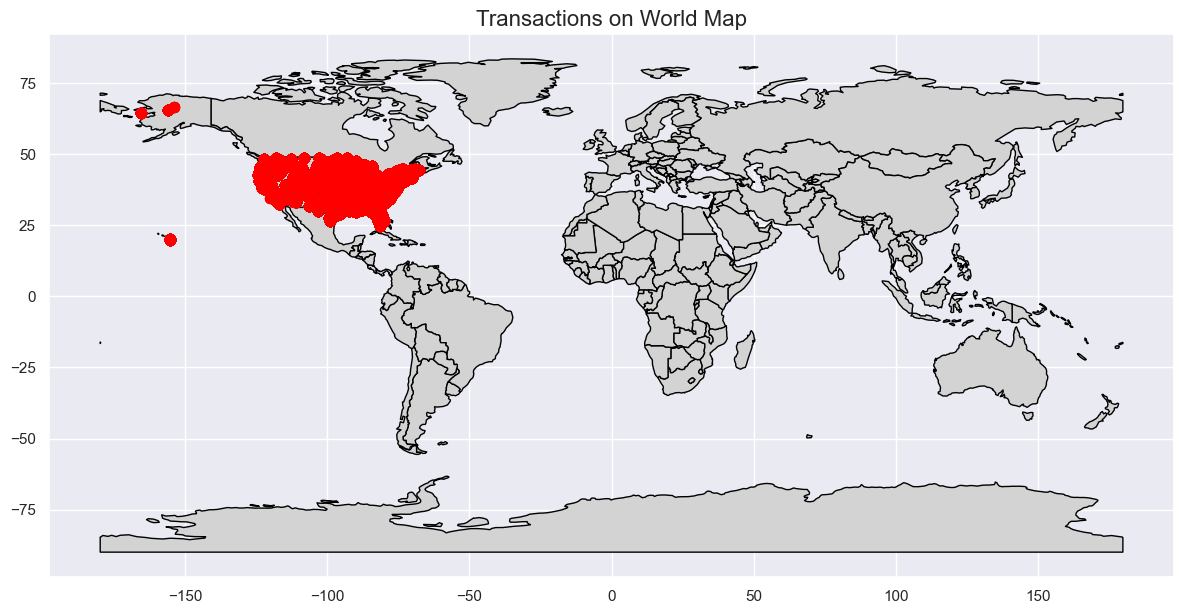

In [19]:
# Load your shapefile
shapefile_path = 'cultural/ne_110m_admin_0_countries.shp'
world = gpd.read_file(shapefile_path)

# Convert to GeoDataFrame
geometry = [Point(xy) for xy in zip(fraud_train['long'], fraud_train['lat'])]
geo_df = gpd.GeoDataFrame(fraud_train, geometry=geometry)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
world.plot(ax=ax, color='lightgrey', edgecolor='black')
geo_df.plot(ax=ax, color='red', markersize=50, alpha=0.7)

# Set title and labels
ax.set_title('Transactions on World Map', fontsize=16)
plt.tight_layout()
plt.show()


In [20]:
def label_states (row):
    if row['state'] in ['CT','ME','MA','NH','NJ','NY','PA','RI','VT']:
        return 'Northeast'
    if row['state'] in ['IL','IN','IA','KS','MI','MN','MO','NE','ND','OH','SD','WI']:
        return 'Midwest'
    if row['state'] in ['AL','AR','DE','DC','FL','GA','KY','LA','MD','MS','NC','OK','SC','TN','Tx','VA','WV']:
        return 'South'
    else:
        return 'West'
fraud_train['state_bin'] = fraud_train.apply(lambda row: label_states(row), axis=1)
fraud_train

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_Date,trans_Time,age,state_bin
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,NC,28654,...,1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,2019-01-01,00:00:18,30,South
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,WA,99160,...,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,2019-01-01,00:00:44,40,West
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,ID,83252,...,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,2019-01-01,00:00:51,56,West
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,...,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,2019-01-01,00:01:16,51,West
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,VA,24433,...,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,2019-01-01,00:03:06,32,South
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,M,162 Jessica Row Apt. 072,Hatch,UT,84735,...,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,2020-06-21,12:12:08,58,West
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,...,1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,2020-06-21,12:12:19,40,South
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,...,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,2020-06-21,12:12:32,52,West
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,42933 Ryan Underpass,Manderson,SD,57756,...,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,2020-06-21,12:13:36,39,Midwest


In [21]:
# Mapping of state abbreviations to full names
state_mapping = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming', 'DC': 'District of Columbia'
}

# Update the 'state' column in fraud_train with full state names
fraud_train['state'] = fraud_train['state'].map(state_mapping)

# Check the updated values
print(fraud_train['state'].unique())


['North Carolina' 'Washington' 'Idaho' 'Montana' 'Virginia' 'Pennsylvania'
 'Kansas' 'Tennessee' 'Iowa' 'West Virginia' 'Florida' 'California'
 'New Mexico' 'New Jersey' 'Oklahoma' 'Indiana' 'Massachusetts' 'Texas'
 'Wisconsin' 'Michigan' 'Wyoming' 'Hawaii' 'Nebraska' 'Oregon' 'Louisiana'
 'District of Columbia' 'Kentucky' 'New York' 'Mississippi' 'Utah'
 'Alabama' 'Arkansas' 'Maryland' 'Georgia' 'Maine' 'Arizona' 'Minnesota'
 'Ohio' 'Colorado' 'Vermont' 'Missouri' 'South Carolina' 'Nevada'
 'Illinois' 'New Hampshire' 'South Dakota' 'Alaska' 'North Dakota'
 'Connecticut' 'Rhode Island' 'Delaware']


In [22]:
fraud_train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_Date,trans_Time,age,state_bin
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,561 Perry Cove,Moravian Falls,North Carolina,28654,...,1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,2019-01-01,00:00:18,30,South
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,43039 Riley Greens Suite 393,Orient,Washington,99160,...,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,2019-01-01,00:00:44,40,West
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,594 White Dale Suite 530,Malad City,Idaho,83252,...,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,2019-01-01,00:00:51,56,West
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,9443 Cynthia Court Apt. 038,Boulder,Montana,59632,...,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,2019-01-01,00:01:16,51,West
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,408 Bradley Rest,Doe Hill,Virginia,24433,...,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,2019-01-01,00:03:06,32,South


In [23]:
fraud_data = fraud_train[fraud_train['is_fraud'] == 1]
fraud_data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_Date,trans_Time,age,state_bin
2449,2019-01-02 01:06:37,4613314721966,fraud_Rutherford-Mertz,grocery_pos,281.06,M,542 Steve Curve Suite 011,Collettsville,North Carolina,28611,...,1988-09-15,e8a81877ae9a0a7f883e15cb39dc4022,1325466397,36.430124,-81.179483,1,2019-01-02,01:06:37,30,South
2472,2019-01-02 01:47:29,340187018810220,"fraud_Jenkins, Hauck and Friesen",gas_transport,11.52,F,27954 Hall Mill Suite 575,San Antonio,Texas,78208,...,1960-10-28,bc7d41c41103877b03232f03f1f8d3f5,1325468849,29.819364,-99.142791,1,2019-01-02,01:47:29,58,West
2523,2019-01-02 03:05:23,340187018810220,fraud_Goodwin-Nitzsche,grocery_pos,276.31,F,27954 Hall Mill Suite 575,San Antonio,Texas,78208,...,1960-10-28,b98f12f4168391b2203238813df5aa8c,1325473523,29.273085,-98.836360,1,2019-01-02,03:05:23,58,West
2546,2019-01-02 03:38:03,4613314721966,fraud_Erdman-Kertzmann,gas_transport,7.03,M,542 Steve Curve Suite 011,Collettsville,North Carolina,28611,...,1988-09-15,397894a5c4c02e3c61c784001f0f14e4,1325475483,35.909292,-82.091010,1,2019-01-02,03:38:03,30,South
2553,2019-01-02 03:55:47,340187018810220,fraud_Koepp-Parker,grocery_pos,275.73,F,27954 Hall Mill Suite 575,San Antonio,Texas,78208,...,1960-10-28,7863235a750d73a244c07f1fb7f0185a,1325476547,29.786426,-98.683410,1,2019-01-02,03:55:47,58,West
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295399,2020-06-21 01:00:08,3524574586339330,fraud_Kassulke PLC,shopping_net,977.01,F,94225 Smith Springs Apt. 617,Vero Beach,Florida,32960,...,1986-05-07,a83b093f0c1d9068fa0089f7c722615f,1371776408,26.888686,-80.834389,1,2020-06-21,01:00:08,34,South
1295491,2020-06-21 01:53:35,3524574586339330,fraud_Schumm PLC,shopping_net,1210.91,F,94225 Smith Springs Apt. 617,Vero Beach,Florida,32960,...,1986-05-07,f75b35bed13b9e692f170dba45a15b21,1371779615,28.216707,-79.855648,1,2020-06-21,01:53:35,34,South
1295532,2020-06-21 02:16:56,4005676619255478,"fraud_Tillman, Dickinson and Labadie",gas_transport,10.24,M,458 Phillips Island Apt. 768,Denham Springs,Louisiana,70726,...,1994-05-31,a0ba2472cd3fc9731f2a18d3f308f5c3,1371781016,29.700456,-91.361632,1,2020-06-21,02:16:56,26,South
1295666,2020-06-21 03:26:20,3560725013359375,fraud_Corwin-Collins,gas_transport,21.69,F,63542 Luna Brook Apt. 012,Notrees,Texas,79759,...,1969-09-15,daa281350b1e16093c7b4bf97bf4d6ed,1371785180,32.675272,-103.484949,1,2020-06-21,03:26:20,50,West


In [24]:
fraud_data['month'] = pd.to_datetime(fraud_data['trans_Date']).dt.to_period('M')

In [25]:
fraud_data['month'] = fraud_data['month'].astype('period[M]')

In [26]:
# Extract year and month
fraud_data['year'] = fraud_data['month'].dt.year
fraud_data['month_num'] = fraud_data['month'].dt.month

In [27]:
fraud_data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,merch_lat,merch_long,is_fraud,trans_Date,trans_Time,age,state_bin,month,year,month_num
2449,2019-01-02 01:06:37,4613314721966,fraud_Rutherford-Mertz,grocery_pos,281.06,M,542 Steve Curve Suite 011,Collettsville,North Carolina,28611,...,36.430124,-81.179483,1,2019-01-02,01:06:37,30,South,2019-01,2019,1
2472,2019-01-02 01:47:29,340187018810220,"fraud_Jenkins, Hauck and Friesen",gas_transport,11.52,F,27954 Hall Mill Suite 575,San Antonio,Texas,78208,...,29.819364,-99.142791,1,2019-01-02,01:47:29,58,West,2019-01,2019,1
2523,2019-01-02 03:05:23,340187018810220,fraud_Goodwin-Nitzsche,grocery_pos,276.31,F,27954 Hall Mill Suite 575,San Antonio,Texas,78208,...,29.273085,-98.836360,1,2019-01-02,03:05:23,58,West,2019-01,2019,1
2546,2019-01-02 03:38:03,4613314721966,fraud_Erdman-Kertzmann,gas_transport,7.03,M,542 Steve Curve Suite 011,Collettsville,North Carolina,28611,...,35.909292,-82.091010,1,2019-01-02,03:38:03,30,South,2019-01,2019,1
2553,2019-01-02 03:55:47,340187018810220,fraud_Koepp-Parker,grocery_pos,275.73,F,27954 Hall Mill Suite 575,San Antonio,Texas,78208,...,29.786426,-98.683410,1,2019-01-02,03:55:47,58,West,2019-01,2019,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295399,2020-06-21 01:00:08,3524574586339330,fraud_Kassulke PLC,shopping_net,977.01,F,94225 Smith Springs Apt. 617,Vero Beach,Florida,32960,...,26.888686,-80.834389,1,2020-06-21,01:00:08,34,South,2020-06,2020,6
1295491,2020-06-21 01:53:35,3524574586339330,fraud_Schumm PLC,shopping_net,1210.91,F,94225 Smith Springs Apt. 617,Vero Beach,Florida,32960,...,28.216707,-79.855648,1,2020-06-21,01:53:35,34,South,2020-06,2020,6
1295532,2020-06-21 02:16:56,4005676619255478,"fraud_Tillman, Dickinson and Labadie",gas_transport,10.24,M,458 Phillips Island Apt. 768,Denham Springs,Louisiana,70726,...,29.700456,-91.361632,1,2020-06-21,02:16:56,26,South,2020-06,2020,6
1295666,2020-06-21 03:26:20,3560725013359375,fraud_Corwin-Collins,gas_transport,21.69,F,63542 Luna Brook Apt. 012,Notrees,Texas,79759,...,32.675272,-103.484949,1,2020-06-21,03:26:20,50,West,2020-06,2020,6


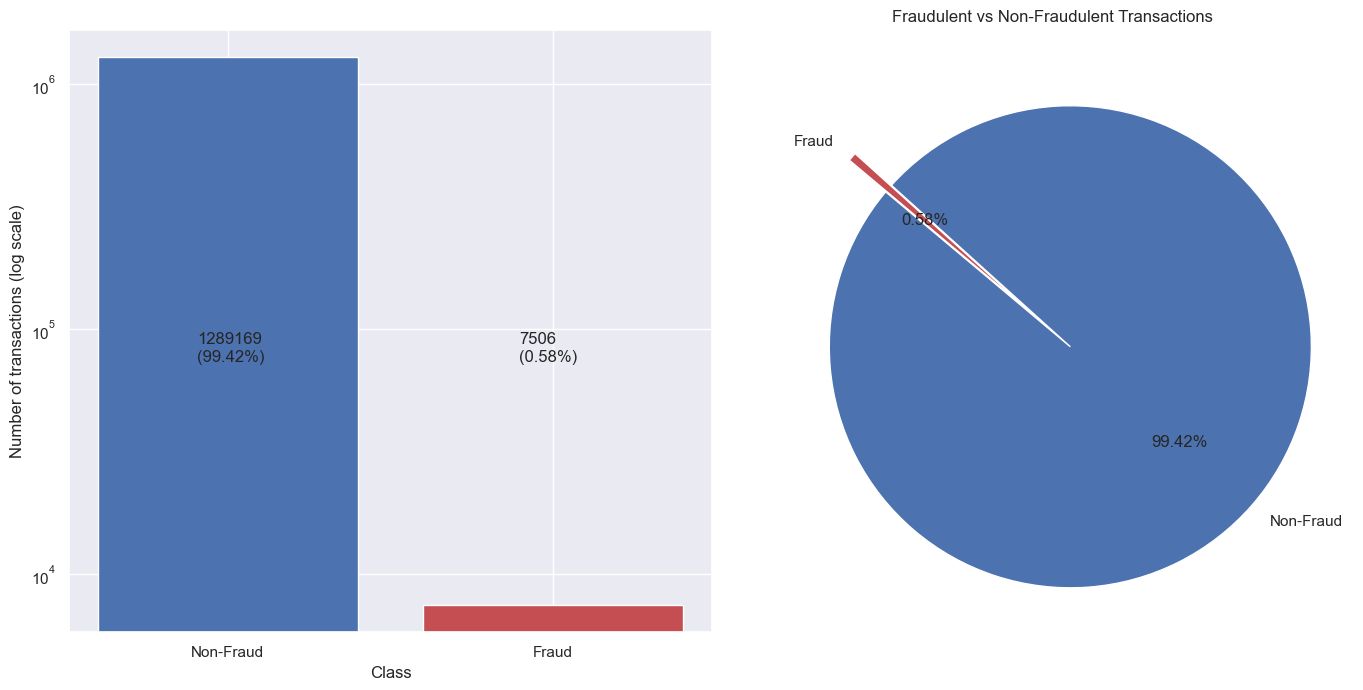

In [28]:
fraud_counts = fraud_train['is_fraud'].value_counts()
fraud_total = fraud_train['is_fraud'].count()

# Create the figure and subplots
fig = plt.figure(figsize=(14, 7))

# Bar plot with logarithmic scale
plt.subplot(1, 2, 1)
plt.bar(['Non-Fraud', 'Fraud'], fraud_counts, color=['b', 'r'])
plt.yscale('log')  # Use logarithmic scale
plt.xlabel('Class')
plt.ylabel('Number of transactions (log scale)')
plt.annotate('{}\n({:.2f}%)'.format(fraud_counts[0], 
                                    fraud_counts[0] / fraud_total * 100),
             (0.20, 0.45), xycoords='axes fraction')
plt.annotate('{}\n({:.2f}%)'.format(fraud_counts[1], 
                                    fraud_counts[1] / fraud_total * 100),
             (0.70, 0.45), xycoords='axes fraction')

# Pie chart with adjusted display
plt.subplot(1, 2, 2)
# Define the labels and values
labels = ['Non-Fraud', 'Fraud']
sizes = fraud_counts
colors = ['b', 'r']
explode = (0.1, 0.1)  # Explode both slices slightly

# Plot pie chart
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.2f%%', colors=colors, startangle=140)
plt.title('Fraudulent vs Non-Fraudulent Transactions')

# Show the plots
plt.tight_layout()
plt.show()


In [29]:
cor = fraud_train.corr()
cor

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,age
cc_num,1.000000,0.001769,0.041459,-0.059271,-0.048278,-0.008991,0.000354,-0.058942,-0.048252,-0.000981,-0.001225
amt,0.001769,1.000000,0.001843,-0.001926,-0.000187,0.005818,-0.000293,-0.001873,-0.000151,0.219404,-0.009755
zip,0.041459,0.001843,1.000000,-0.114290,-0.909732,0.078467,0.000670,-0.113561,-0.908924,-0.002162,0.010699
lat,-0.059271,-0.001926,-0.114290,1.000000,-0.015533,-0.155730,0.000632,0.993592,-0.015509,0.001894,0.047891
long,-0.048278,-0.000187,-0.909732,-0.015533,1.000000,-0.052715,-0.000642,-0.015452,0.999120,0.001721,-0.029919
city_pop,-0.008991,0.005818,0.078467,-0.155730,-0.052715,1.000000,-0.001714,-0.154781,-0.052687,0.002136,-0.092433
unix_time,0.000354,-0.000293,0.000670,0.000632,-0.000642,-0.001714,1.000000,0.000561,-0.000635,-0.005078,0.019739
merch_lat,-0.058942,-0.001873,-0.113561,0.993592,-0.015452,-0.154781,0.000561,1.000000,-0.015431,0.001741,0.047503
merch_long,-0.048252,-0.000151,-0.908924,-0.015509,0.999120,-0.052687,-0.000635,-0.015431,1.000000,0.001721,-0.029843
is_fraud,-0.000981,0.219404,-0.002162,0.001894,0.001721,0.002136,-0.005078,0.001741,0.001721,1.000000,0.012248


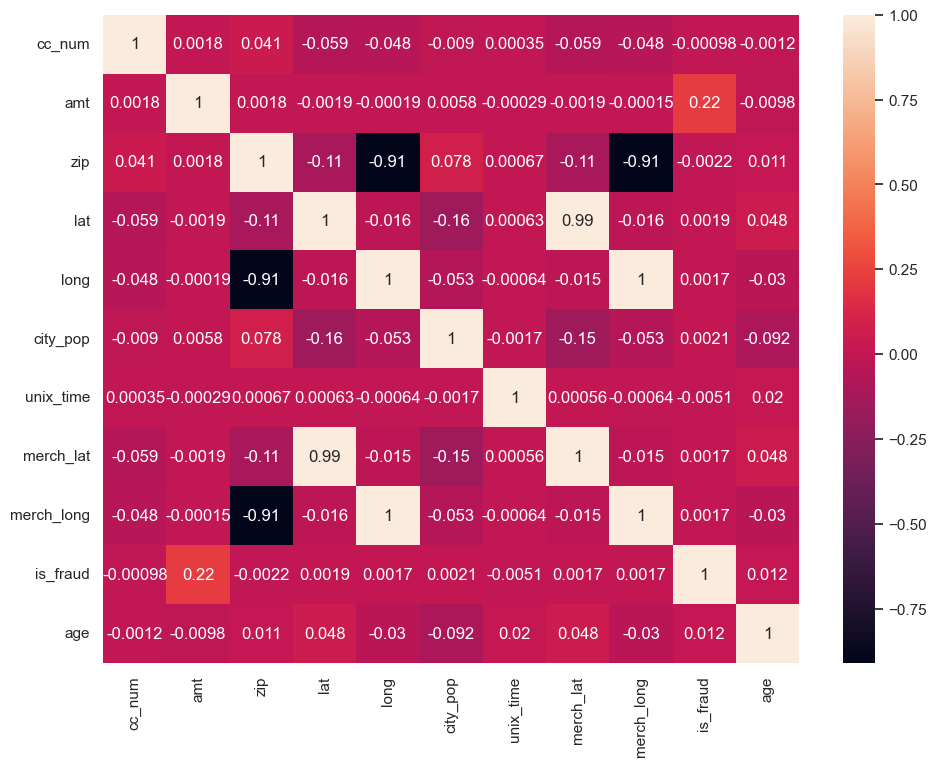

In [30]:
# Checking the coorelations between the variables
plt.figure(figsize=(10,8))
sns.heatmap(fraud_train.corr(), annot= True)
plt.show()

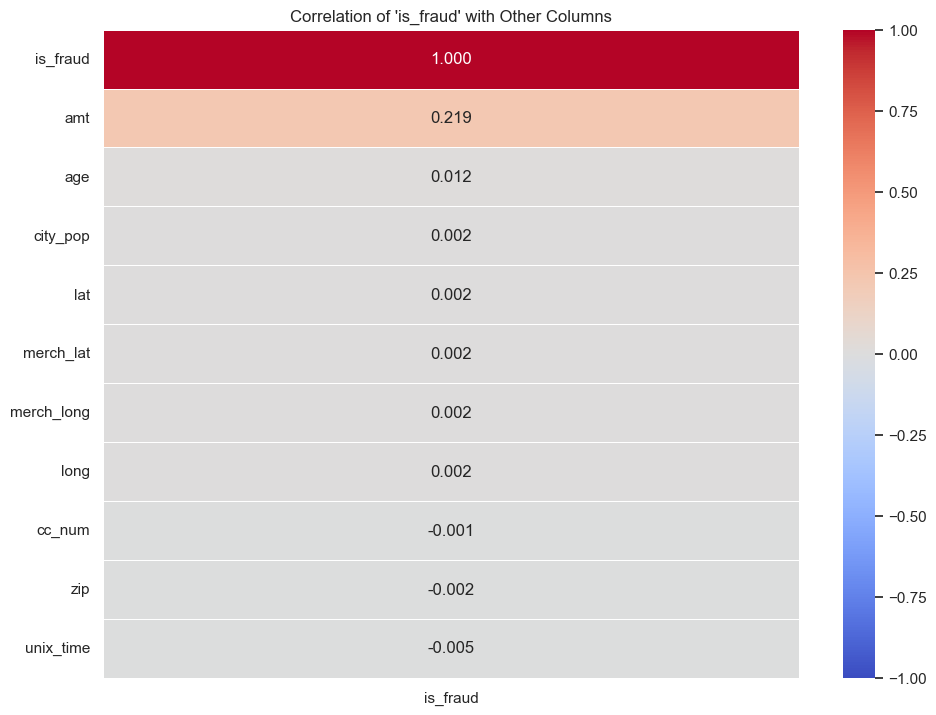

In [31]:
# Correlation of Target column with other numeric input features
# Compute the correlation matrix
corr_matrix = fraud_train.corr()

# Extract correlations with 'is_fraud'
correlation_with_fraud = corr_matrix[['is_fraud']].sort_values(by='is_fraud', ascending=False)

# Set up the figure
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(correlation_with_fraud, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.3f', linewidths=0.5)

# Set title and labels
plt.title('Correlation of \'is_fraud\' with Other Columns')
plt.show()


In [32]:
fraud_data = fraud_train[fraud_train['is_fraud'] == 1]

In [33]:
fraud_data['hour'] = fraud_data['trans_date_trans_time'].dt.hour

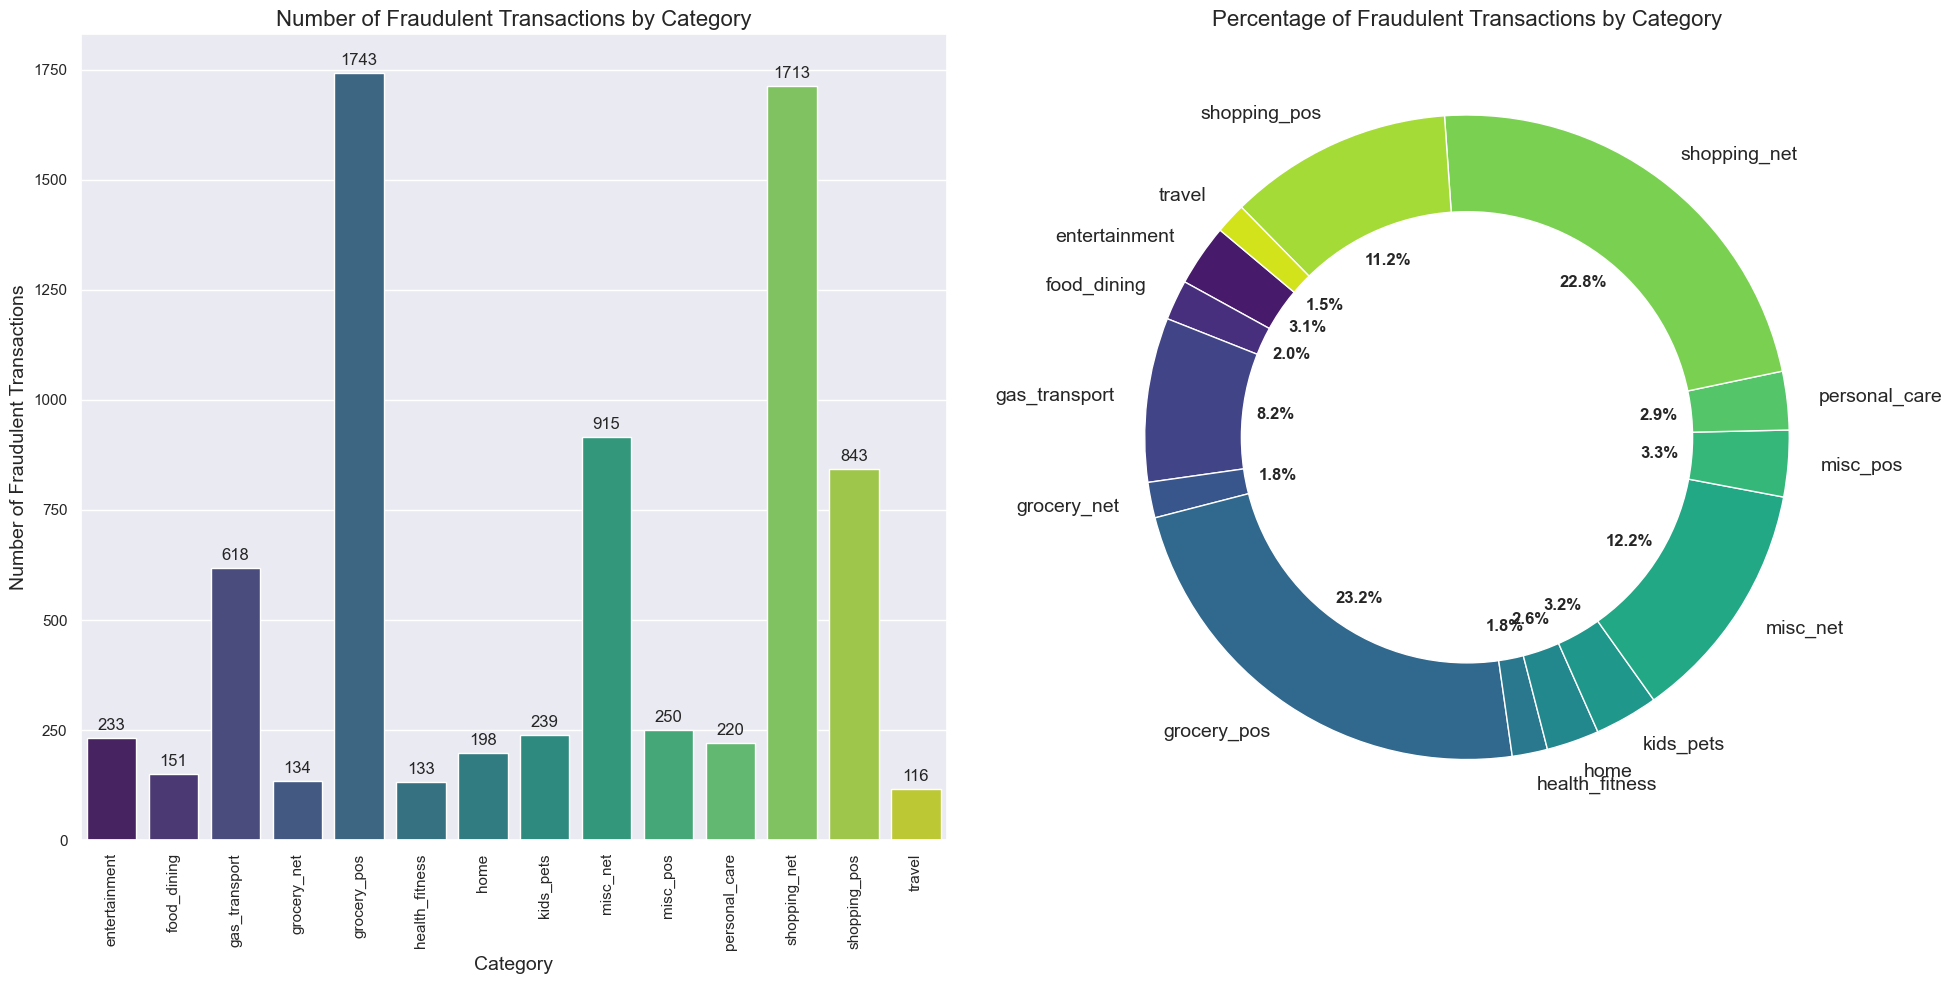

In [34]:
# Group by the category and count occurrences
fraud_by_category = fraud_data.groupby('category').size()

# Define a color palette for consistency
colors = sns.color_palette("viridis", len(fraud_by_category))

# Create a figure with two subplots: a bar chart and a pie chart
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Subplot 1: Bar Chart
sns.barplot(x=fraud_by_category.index, y=fraud_by_category.values, palette=colors, ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
ax[0].set_title('Number of Fraudulent Transactions by Category', fontsize=16)
ax[0].set_xlabel('Category', fontsize=14)
ax[0].set_ylabel('Number of Fraudulent Transactions', fontsize=14)

# Adding annotations to bar chart
for p in ax[0].patches:
    ax[0].annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 9),  # 9 points vertical offset
                   textcoords='offset points',
                   fontsize=12)

# Subplot 2: Pie Chart
wedges, texts, autotexts = ax[1].pie(fraud_by_category, labels=fraud_by_category.index, autopct='%1.1f%%', startangle=140, colors=colors)

# Adding a circle at the center for a donut chart
centre_circle = plt.Circle((0, 0), 0.7, fc='white')
fig.gca().add_artist(centre_circle)

# Formatting pie chart
ax[1].set_title('Percentage of Fraudulent Transactions by Category', fontsize=16)

# Formatting pie chart text
plt.setp(autotexts, size=12, weight="bold")
plt.setp(texts, size=14)

# Display the plots
plt.tight_layout()
plt.show()


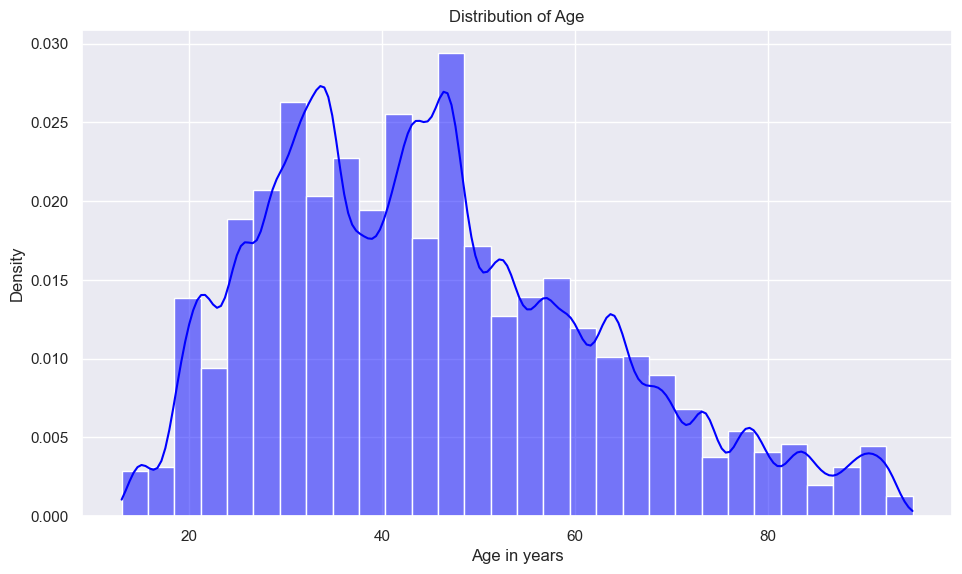

In [35]:
# Plot the normalized histogram (density plot)
plt.figure(figsize=(10, 6))
ax = sns.histplot(fraud_train['age'], kde=True, stat='density', bins=30, color='blue')

# Set labels and title
ax.set_ylabel('Density')
ax.set_xlabel('Age in years')
ax.set_title('Distribution of Age')

plt.show()


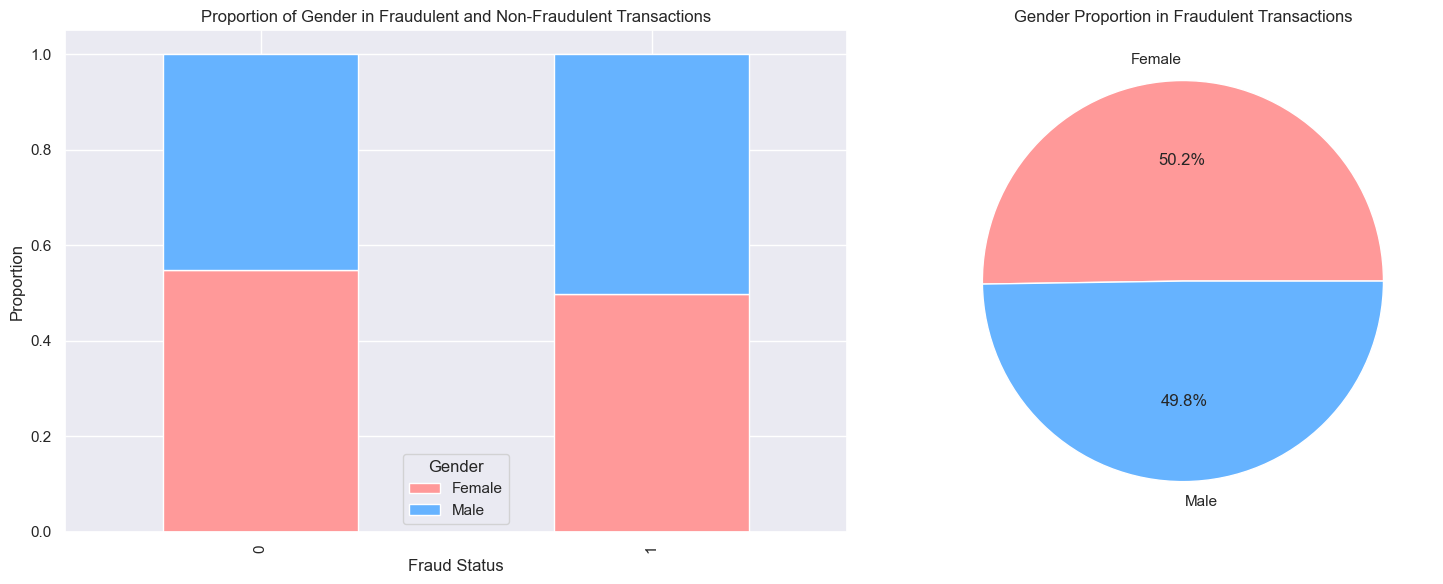

In [36]:
# Ensure gender is categorical and convert to numeric codes
fraud_train['gender'] = fraud_train['gender'].astype('category')  
#fraud_train['gender'] = fraud_train['gender'].cat.codes  

# Calculate proportions of gender in fraudulent and non-fraudulent transactions
total_counts = fraud_train.groupby('is_fraud')['gender'].value_counts(normalize=True).unstack()
total_counts = total_counts.fillna(0)  # Fill NaN values with 0

# Calculate gender proportions only for fraudulent transactions
fraudulent_transactions = fraud_train[fraud_train['is_fraud'] == 1]
gender_proportions = fraudulent_transactions['gender'].value_counts(normalize=True)

# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot the bar chart
total_counts.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=axes[0])
axes[0].set_xlabel('Fraud Status')
axes[0].set_ylabel('Proportion')
axes[0].set_title('Proportion of Gender in Fraudulent and Non-Fraudulent Transactions')
axes[0].legend(title='Gender', labels=['Female', 'Male'])

# Plot the pie chart for only fraudulent transactions
axes[1].pie(gender_proportions, labels=['Female', 'Male'], autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'])
axes[1].set_title('Gender Proportion in Fraudulent Transactions')

plt.tight_layout()
plt.show()


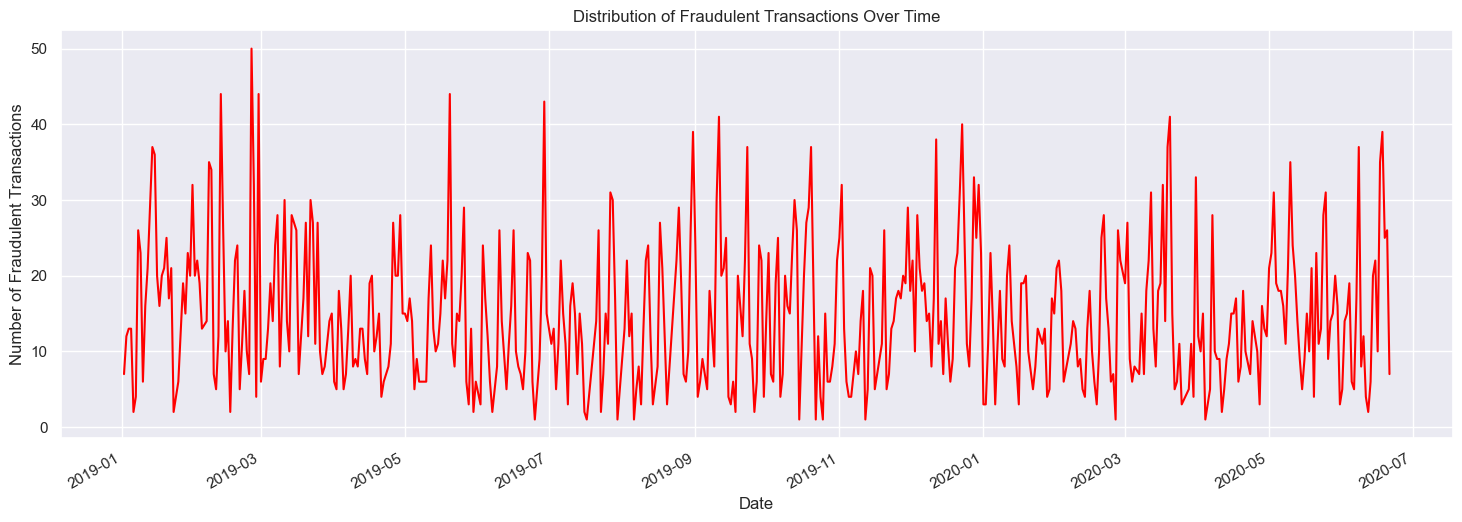

In [37]:
# Step 1: Group by the transaction date and count the occurrences
fraud_over_time = fraud_data.groupby('trans_Date').size()

# Step 2: Plot the results
plt.figure(figsize=(16, 6))
fraud_over_time.plot(kind='line', color='red')
plt.title('Distribution of Fraudulent Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Fraudulent Transactions')
plt.grid(True)
plt.show()


In [38]:
fraud_data

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,...,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_Date,trans_Time,age,state_bin,hour
2449,2019-01-02 01:06:37,4613314721966,fraud_Rutherford-Mertz,grocery_pos,281.06,M,542 Steve Curve Suite 011,Collettsville,North Carolina,28611,...,e8a81877ae9a0a7f883e15cb39dc4022,1325466397,36.430124,-81.179483,1,2019-01-02,01:06:37,30,South,1
2472,2019-01-02 01:47:29,340187018810220,"fraud_Jenkins, Hauck and Friesen",gas_transport,11.52,F,27954 Hall Mill Suite 575,San Antonio,Texas,78208,...,bc7d41c41103877b03232f03f1f8d3f5,1325468849,29.819364,-99.142791,1,2019-01-02,01:47:29,58,West,1
2523,2019-01-02 03:05:23,340187018810220,fraud_Goodwin-Nitzsche,grocery_pos,276.31,F,27954 Hall Mill Suite 575,San Antonio,Texas,78208,...,b98f12f4168391b2203238813df5aa8c,1325473523,29.273085,-98.836360,1,2019-01-02,03:05:23,58,West,3
2546,2019-01-02 03:38:03,4613314721966,fraud_Erdman-Kertzmann,gas_transport,7.03,M,542 Steve Curve Suite 011,Collettsville,North Carolina,28611,...,397894a5c4c02e3c61c784001f0f14e4,1325475483,35.909292,-82.091010,1,2019-01-02,03:38:03,30,South,3
2553,2019-01-02 03:55:47,340187018810220,fraud_Koepp-Parker,grocery_pos,275.73,F,27954 Hall Mill Suite 575,San Antonio,Texas,78208,...,7863235a750d73a244c07f1fb7f0185a,1325476547,29.786426,-98.683410,1,2019-01-02,03:55:47,58,West,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295399,2020-06-21 01:00:08,3524574586339330,fraud_Kassulke PLC,shopping_net,977.01,F,94225 Smith Springs Apt. 617,Vero Beach,Florida,32960,...,a83b093f0c1d9068fa0089f7c722615f,1371776408,26.888686,-80.834389,1,2020-06-21,01:00:08,34,South,1
1295491,2020-06-21 01:53:35,3524574586339330,fraud_Schumm PLC,shopping_net,1210.91,F,94225 Smith Springs Apt. 617,Vero Beach,Florida,32960,...,f75b35bed13b9e692f170dba45a15b21,1371779615,28.216707,-79.855648,1,2020-06-21,01:53:35,34,South,1
1295532,2020-06-21 02:16:56,4005676619255478,"fraud_Tillman, Dickinson and Labadie",gas_transport,10.24,M,458 Phillips Island Apt. 768,Denham Springs,Louisiana,70726,...,a0ba2472cd3fc9731f2a18d3f308f5c3,1371781016,29.700456,-91.361632,1,2020-06-21,02:16:56,26,South,2
1295666,2020-06-21 03:26:20,3560725013359375,fraud_Corwin-Collins,gas_transport,21.69,F,63542 Luna Brook Apt. 012,Notrees,Texas,79759,...,daa281350b1e16093c7b4bf97bf4d6ed,1371785180,32.675272,-103.484949,1,2020-06-21,03:26:20,50,West,3


In [39]:
# Filter the dataset for months January to June and years 2019 and 2020
fraud_data_filtered = fraud_data[(fraud_data['month_num'].between(1, 6)) & (fraud_data['year'].isin([2019, 2020]))]

# Group by year and month, and count the number of fraudulent transactions
fraud_counts = fraud_data_filtered.groupby(['year', 'month_num']).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(16, 6))
for year in [2019, 2020]:
    plt.plot(fraud_counts.columns, fraud_counts.loc[year], label=str(year), marker='o')

# Formatting
plt.title('Distribution of Fraudulent Transactions (Jan - Jun) for 2019 and 2020')
plt.xlabel('Month')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(ticks=range(1, 7), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])
plt.legend(title='Year')
plt.grid(True)
plt.show()


KeyError: 'month_num'

In [ ]:
# Step 1: Filter the data for the first six months of 2019 and 2020
fraud_2019 = fraud_data[(fraud_data['trans_Date'] >= '2019-01-01') & (fraud_data['trans_Date'] < '2019-07-01')]
fraud_2020 = fraud_data[(fraud_data['trans_Date'] >= '2020-01-01') & (fraud_data['trans_Date'] < '2020-07-01')]

# Step 2: Group by month and sum the 'amt' for each year
fraud_2019_over_time = fraud_2019.groupby(fraud_2019['trans_Date'].dt.to_period('M'))['amt'].sum()
fraud_2020_over_time = fraud_2020.groupby(fraud_2020['trans_Date'].dt.to_period('M'))['amt'].sum()

# Step 3: Create a bar chart with bars for 2019 and 2020 side by side
months = fraud_2019_over_time.index.strftime('%b')  # Convert to month names for labels
indices = np.arange(len(months))  # Generate the indices for the x-axis

bar_width = 0.35  # Width of the bars

plt.figure(figsize=(12, 6))
plt.bar(indices, fraud_2019_over_time, width=bar_width, color='blue', label='2019')
plt.bar(indices + bar_width, fraud_2020_over_time, width=bar_width, color='green', label='2020')

plt.title('Comparison of Total Fraudulent Transaction Amounts: First 6 Months of 2019 vs. 2020')
plt.xlabel('Month')
plt.ylabel('Total Transaction Amount ($)')
plt.xticks(indices + bar_width / 2, months)  # Set x-ticks in the middle of the group
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Create a figure
fig = plt.figure(figsize=(10, 6))

# Create the count plot
ax = sns.countplot(x='state_bin', data=fraud_data, palette='viridis')

# Set the title and axis labels
ax.set_title('Distribution of Fraudulent Transactions by State Bin', fontsize=16)
ax.set_xlabel('State Bin', fontsize=14)
ax.set_ylabel('Number of Fraudulent Transactions', fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add annotations to each bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),  # 5 points vertical offset
                textcoords='offset points',
                fontsize=12, color='black')

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
# Create GeoDataFrame for customer locations
customer_geometry = [Point(xy) for xy in zip(fraud_data['long'], fraud_data['lat'])]
geo_customer_df = gpd.GeoDataFrame(fraud_data, geometry=customer_geometry)

# Create GeoDataFrame for merchant locations
merchant_geometry = [Point(xy) for xy in zip(fraud_data['merch_long'], fraud_data['merch_lat'])]
geo_merchant_df = gpd.GeoDataFrame(fraud_data, geometry=merchant_geometry)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot customer locations
world.plot(ax=axes[0], color='lightgrey', edgecolor='black')
geo_customer_df.plot(ax=axes[0], color='red', markersize=0.3, alpha=0.7, label='Customer Locations')
axes[0].set_title('Customer Locations on World Map', fontsize=16)
axes[0].set_xlabel('Longitude', fontsize=14)
axes[0].set_ylabel('Latitude', fontsize=14)
axes[0].legend()

# Plot merchant locations
world.plot(ax=axes[1], color='lightgrey', edgecolor='black')
geo_merchant_df.plot(ax=axes[1], color='blue', markersize=0.3, alpha=0.7, label='Merchant Locations')
axes[1].set_title('Merchant Locations on World Map', fontsize=16)
axes[1].set_xlabel('Longitude', fontsize=14)
axes[1].set_ylabel('Latitude', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# Group by state and calculate the sum of 'amt' and count of fraudulent transactions
state_fraud_summary = fraud_data.groupby('state').agg({
    'amt': 'sum',
    'is_fraud': 'count'
}).rename(columns={'is_fraud': 'count'})

# Sort by the total amount involved and select top 10
top_10_states = state_fraud_summary.sort_values(by='amt', ascending=False)

# Plot
fig, ax1 = plt.subplots(figsize=(12, 8))

color = 'tab:blue'
ax1.set_xlabel('State')
ax1.set_ylabel('Total Amount Involved ($)', color=color)
ax1.bar(top_10_states.index, top_10_states['amt'], color=color, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)

# Rotate x-axis labels
plt.xticks(rotation=90)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Number of Fraudulent Transactions', color=color)  # we already handled the x-label with ax1
ax2.plot(top_10_states.index, top_10_states['count'], color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout() 

plt.title('Top 10 States for Fraudulent Transactions')
plt.show()


In [ ]:
# Group by state and calculate the sum of 'amt' and count of fraudulent transactions
state_fraud_summary = fraud_data.groupby('state').agg({
    'amt': 'sum',
    'is_fraud': 'count'
}).rename(columns={'is_fraud': 'count'})

# Sort by the total amount involved and select top 10
top_10_states = state_fraud_summary.sort_values(by='amt', ascending=False).head(10)

# Plot
fig, ax1 = plt.subplots(figsize=(12, 8))

color = 'tab:blue'
ax1.set_xlabel('State')
ax1.set_ylabel('Total Amount Involved ($)', color=color)
ax1.bar(top_10_states.index, top_10_states['amt'], color=color, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Number of Fraudulent Transactions', color=color)  # we already handled the x-label with ax1
ax2.plot(top_10_states.index, top_10_states['count'], color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Top 10 States for Fraudulent Transactions')
plt.show()


In [ ]:
# Get the counts of fraudulent transactions per state
state_fraud_counts = fraud_data['state'].value_counts()

# Select the top 10 states with the highest counts
top_10_states = state_fraud_counts.head(10)

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(top_10_states, labels=top_10_states.index, autopct='%1.1f%%', startangle=140)
plt.title('Percentage of Top 10 States in Fraudulent Transactions')
plt.show()


In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='state', y='amt', data=fraud_data)
plt.xticks(rotation=90)
plt.title('Box Plot of Fraudulent Transaction Amounts by State')
plt.xlabel('State')
plt.ylabel('Transaction Amount')
plt.grid(True)
plt.show()


In [ ]:
heatmap_data = fraud_data.groupby(['state', 'month']).size().unstack(fill_value=0)

plt.figure(figsize=(20, 16))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt="d")
plt.title('Heatmap of Fraudulent Transactions by State and Month')
plt.xlabel('Month')
plt.ylabel('State')
plt.show()


In [ ]:
# Calculate the mean transaction amount by gender and category
mean_transaction_amount = fraud_data.groupby(['gender', 'category'])['amt'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(data=mean_transaction_amount, x='category', y='amt', hue='gender', palette='Set2')

plt.yscale('log')  # Apply a logarithmic scale to the y-axis

plt.title('Mean Transaction Amount by Gender and Category')
plt.xlabel('Category')
plt.ylabel('Mean Transaction Amount (Log Scale)')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.grid(True, linestyle='--', alpha=0.7, which='both')
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(x='hour', hue='gender', data=fraud_data, multiple='stack', bins=24, palette='Set2')
plt.xlabel('Hour of Day')
plt.ylabel('Transaction Count')
plt.title('Distribution of Transaction Times by Gender')

# Apply logarithmic scale to the y-axis
plt.yscale('log')

plt.legend(title='Gender', labels=['Female', 'Male'])
plt.grid(True)
plt.show()


In [ ]:

plt.figure(figsize=(10, 6))
sns.histplot(x='hour', hue='gender', data=fraud_data, multiple='stack', bins=24, palette='Set2')
plt.xlabel('Hour of Day')
plt.ylabel('Transaction Count')
plt.title('Distribution of Transaction Times by Gender')
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.grid(True)
plt.show()

In [ ]:
# Step 1: Group by category and cc_num to count the number of fraudulent transactions
cc_fraud_count = fraud_data.groupby(['category', 'cc_num']).size().reset_index(name='count')

# Step 3: Find the credit card number with the highest count in each category
top_cc_by_category = cc_fraud_count.loc[cc_fraud_count.groupby('category')['count'].idxmax()]

# Step 4: Visualize the results
plt.figure(figsize=(12, 8))
plt.barh(top_cc_by_category['category'], top_cc_by_category['count'], color='skyblue')
plt.xlabel('Number of Fraudulent Transactions')
plt.ylabel('Category')
plt.title('Credit Card with Most Fraudulent Transactions in Each Category')
plt.show()
